# **Extracción**

In [20]:
import pandas as pd 
import requests

import numpy as np
import matplotlib.pyplot as plt

In [21]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [22]:
response = requests.get(url)
print(response.status_code) 

200


In [23]:
data = response.json()
type(data)

list

In [24]:
data = pd.json_normalize(data)

# **Transformación**

In [25]:
data.shape

(7267, 21)

In [26]:
data.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [27]:
data.tail()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65
7266,9995-HOTOH,No,Male,0,Yes,Yes,63,No,No phone service,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Electronic check,59.00,3707.6


In [28]:
data.columns = data.columns.str.lower().str.replace('.', '_')
data.head(2)

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4


In [29]:
data.info()
# Ojo, cambiar el tipo de dato de la columna 'account_charges_total' a numérico 

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7267 non-null   str    
 1   churn                      7267 non-null   str    
 2   customer_gender            7267 non-null   str    
 3   customer_seniorcitizen     7267 non-null   int64  
 4   customer_partner           7267 non-null   str    
 5   customer_dependents        7267 non-null   str    
 6   customer_tenure            7267 non-null   int64  
 7   phone_phoneservice         7267 non-null   str    
 8   phone_multiplelines        7267 non-null   str    
 9   internet_internetservice   7267 non-null   str    
 10  internet_onlinesecurity    7267 non-null   str    
 11  internet_onlinebackup      7267 non-null   str    
 12  internet_deviceprotection  7267 non-null   str    
 13  internet_techsupport       7267 non-null   str    
 14  int

## **Verificaciones**

In [30]:
# Valores únicos 
for col in data.columns:
    print(f'{col}: {data[col].nunique()}')
    if data[col].nunique() < 50:
        print(data[col].unique())
        print('-' * 50)

customerid: 7267
churn: 3
<StringArray>
['No', 'Yes', '']
Length: 3, dtype: str
--------------------------------------------------
customer_gender: 2
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
customer_seniorcitizen: 2
[0 1]
--------------------------------------------------
customer_partner: 2
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
customer_dependents: 2
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
customer_tenure: 73
phone_phoneservice: 2
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
phone_multiplelines: 3
<StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str
--------------------------------------------------
internet_internetservice: 3
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
------------------------------------

In [31]:
# Valores duplicados
print('Numero de duplicados', data.duplicated().sum())

Numero de duplicados 0


In [32]:
# Valores nulos
print('Valores nulos \n',   data.isnull().sum())

Valores nulos 
 customerid                   0
churn                        0
customer_gender              0
customer_seniorcitizen       0
customer_partner             0
customer_dependents          0
customer_tenure              0
phone_phoneservice           0
phone_multiplelines          0
internet_internetservice     0
internet_onlinesecurity      0
internet_onlinebackup        0
internet_deviceprotection    0
internet_techsupport         0
internet_streamingtv         0
internet_streamingmovies     0
account_contract             0
account_paperlessbilling     0
account_paymentmethod        0
account_charges_monthly      0
account_charges_total        0
dtype: int64


In [33]:
# Valores vacíos o en blanco
data.apply(lambda x: x.astype(str).str.strip() == '').sum()

customerid                     0
churn                        224
customer_gender                0
customer_seniorcitizen         0
customer_partner               0
customer_dependents            0
customer_tenure                0
phone_phoneservice             0
phone_multiplelines            0
internet_internetservice       0
internet_onlinesecurity        0
internet_onlinebackup          0
internet_deviceprotection      0
internet_techsupport           0
internet_streamingtv           0
internet_streamingmovies       0
account_contract               0
account_paperlessbilling       0
account_paymentmethod          0
account_charges_monthly        0
account_charges_total         11
dtype: int64

## **Transformaciones**

1. Columna 'account_charges_total'

In [34]:
df_nan_account_charges_total = data[data['account_charges_total'].str.strip() == '']
df_nan_account_charges_total.head(12)
# Ojo: Estos registros tienen en ceros la columna 'account_charges_total' pues 'customer_ternure' está en ceros también

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,


In [35]:
data['account_charges_total'] = pd.to_numeric(data['account_charges_total'], errors='coerce')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7267 non-null   str    
 1   churn                      7267 non-null   str    
 2   customer_gender            7267 non-null   str    
 3   customer_seniorcitizen     7267 non-null   int64  
 4   customer_partner           7267 non-null   str    
 5   customer_dependents        7267 non-null   str    
 6   customer_tenure            7267 non-null   int64  
 7   phone_phoneservice         7267 non-null   str    
 8   phone_multiplelines        7267 non-null   str    
 9   internet_internetservice   7267 non-null   str    
 10  internet_onlinesecurity    7267 non-null   str    
 11  internet_onlinebackup      7267 non-null   str    
 12  internet_deviceprotection  7267 non-null   str    
 13  internet_techsupport       7267 non-null   str    
 14  int

In [36]:
data['account_charges_total'].isna().sum()

np.int64(11)

In [37]:
data['account_charges_total'] = data['account_charges_total'].fillna(0)
data['account_charges_total']

0        593.30
1        542.40
2        280.85
3       1237.85
4        267.40
         ...   
7262     742.90
7263    1873.70
7264      92.75
7265    4627.65
7266    3707.60
Name: account_charges_total, Length: 7267, dtype: float64

In [38]:
data['account_charges_total'].isna().sum()

np.int64(0)

2. Columna 'churn'

In [40]:
data['churn'].unique()
# Ojo: deberían ser sólo 'Yes' o 'No'

<StringArray>
['No', 'Yes', '']
Length: 3, dtype: str

In [41]:
data['churn'].value_counts()

churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

In [42]:
data['churn'] = data['churn'].str.strip().replace("",np.nan)

In [43]:
data['churn'].isna().sum()

np.int64(224)

In [44]:
churn_yes = data.groupby('churn').size()['Yes'] * 100 / len(data)
print(f'Porcentaje de clientes que SÍ han cancelado el servicio: {churn_yes:.2f}%')

Porcentaje de clientes que SÍ han cancelado el servicio: 25.72%


In [45]:
churn_no = data.groupby('churn').size()['No'] * 100 / len(data)
print(f'Porcentaje de clientes que NO han cancelado el servicio: {churn_no:.2f}%')

Porcentaje de clientes que NO han cancelado el servicio: 71.20%


In [46]:
data_churn_nan = data['churn'].isna().sum() * 100 / len(data)
print(f'El pocentaje de valores nan de churn es: {data_churn_nan:.2f}')
# Ojo: como son muy pocas entradas las que son nan, se eliminarán

El pocentaje de valores nan de churn es: 3.08


In [47]:
data = data.dropna(subset=['churn'])

In [48]:
data['churn'].value_counts(dropna=False)

churn
No     5174
Yes    1869
Name: count, dtype: int64

## **Creación de la columna 'daily accounts' (cuentas diarias)**

In [ ]:
data['daily_accounts'] = data['account_charges_monthly']/30

In [53]:
data[['daily_accounts', 'account_charges_monthly']].head()

,daily_accounts,account_charges_monthly
0,2.186667,65.6
1,1.996667,59.9
2,2.463333,73.9
3,3.266667,98.0
4,2.796667,83.9


In [77]:
data.to_csv('TelecomX_data.csv', index = False)

In [54]:
# Transformación a binario de la columna "churn" 
data['churn_bin'] = data['churn'].map({'Yes':1, 'No':0})
data['churn_bin']

0       0
1       0
2       1
3       1
4       1
       ..
7262    0
7263    1
7264    0
7265    0
7266    0
Name: churn_bin, Length: 7043, dtype: int64

In [55]:
data['churn_bin'].value_counts

<bound method IndexOpsMixin.value_counts of 0       0
1       0
2       1
3       1
4       1
       ..
7262    0
7263    1
7264    0
7265    0
7266    0
Name: churn_bin, Length: 7043, dtype: int64>

# **Carga y Análisis**

<function matplotlib.pyplot.show(close=None, block=None)>

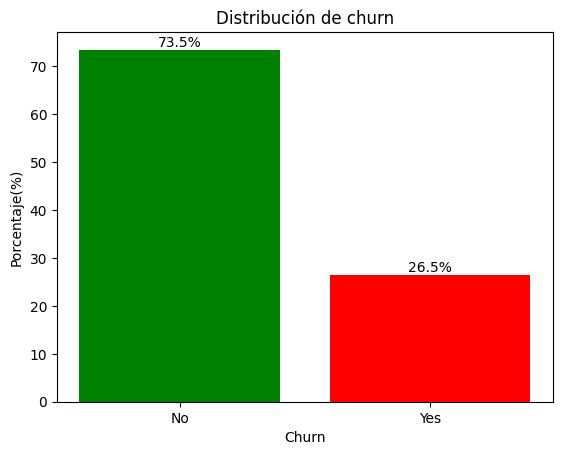

In [56]:
proporciones = data['churn'].value_counts(normalize=True)*100

plt.figure()
bars = plt.bar(proporciones.index.astype(str), 
               proporciones.values,
               color = ['green','red'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.1f}%',
             ha='center', va='bottom')
    
plt.xlabel('Churn')
plt.ylabel('Porcentaje(%)')
plt.title('Distribución de churn')

plt.savefig('imagenes/distribucion_de_churn.png', dpi=300, bbox_inches='tight')
plt.show

In [57]:
data['customer_tenure'].describe().round(2)

count    7043.00
mean       32.37
std        24.56
min         0.00
25%         9.00
50%        29.00
75%        55.00
max        72.00
Name: customer_tenure, dtype: float64

In [58]:
data['account_charges_monthly'].describe().round(2)

count    7043.00
mean       64.76
std        30.09
min        18.25
25%        35.50
50%        70.35
75%        89.85
max       118.75
Name: account_charges_monthly, dtype: float64

In [59]:
data['account_charges_total'].describe().round(2)

count    7043.00
mean     2279.73
std      2266.79
min         0.00
25%       398.55
50%      1394.55
75%      3786.60
max      8684.80
Name: account_charges_total, dtype: float64

In [60]:
data['daily_accounts'].describe().round(2)

count    7043.00
mean        2.16
std         1.00
min         0.61
25%         1.18
50%         2.34
75%         2.99
max         3.96
Name: daily_accounts, dtype: float64

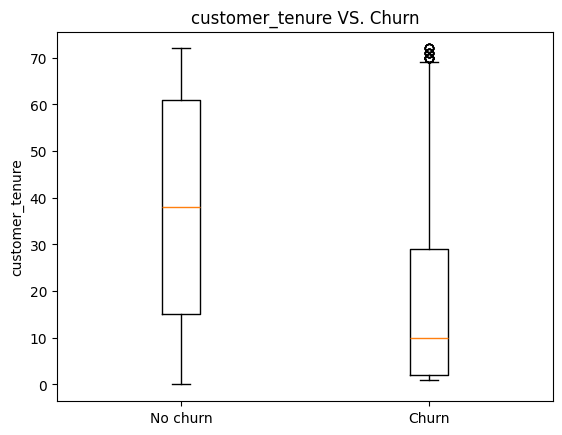

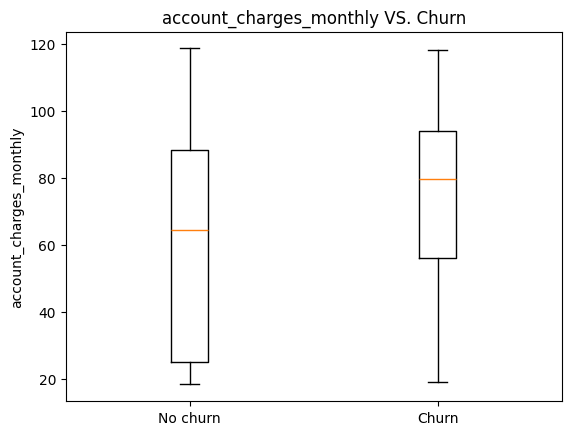

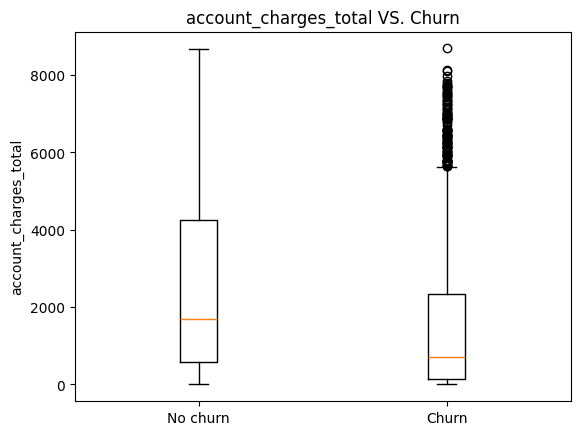

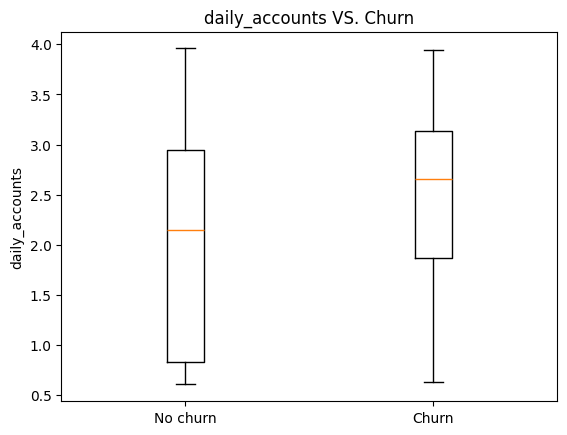

In [61]:
variables_numericas = ['customer_tenure',
                       'account_charges_monthly',
                       'account_charges_total',
                       'daily_accounts']

for variable in variables_numericas:
    plt.figure()
    plt.boxplot([data[data['churn'] == 'No'][variable],
                data[data['churn'] == 'Yes'][variable]])
    plt.xticks([1, 2], ['No churn', 'Churn'])
    plt.ylabel(variable)
    plt.title(f'{variable} VS. Churn')

    plt.savefig(f'imagenes/churn_por_{variable}.png',
            dpi=300,
            bbox_inches='tight')
    plt.show()


In [62]:
pd.crosstab(data['account_contract'], data['churn'], normalize = 'index') * 100

churn,No,Yes
account_contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [63]:
pd.crosstab(data['account_paperlessbilling'], data['churn'], normalize = 'index') * 100

churn,No,Yes
account_paperlessbilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


In [64]:
pd.crosstab(data['churn'], data['account_paymentmethod'], normalize = 'index') * 100

account_paymentmethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
churn,,,,
No,24.855044,24.932354,25.009664,25.202938
Yes,13.804173,12.413055,57.303371,16.479401


In [65]:
pd.crosstab(data['internet_techsupport'], data['churn'], normalize = 'index') * 100

churn,No,Yes
internet_techsupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


In [66]:
pd.crosstab(data['customer_gender'], data['churn'], normalize = 'index') * 100

churn,No,Yes
customer_gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


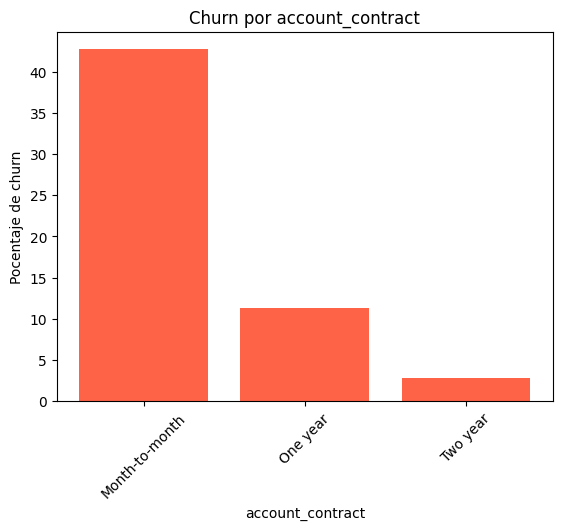

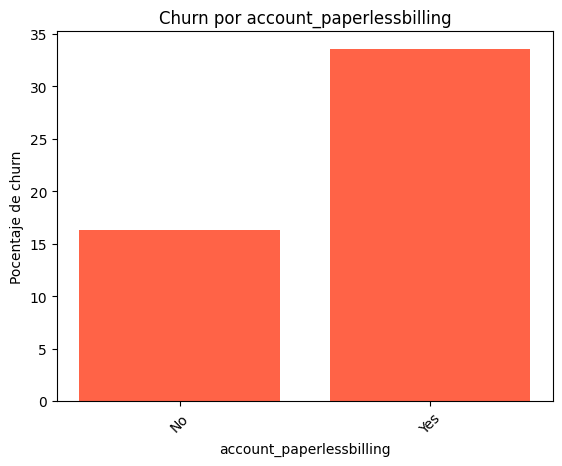

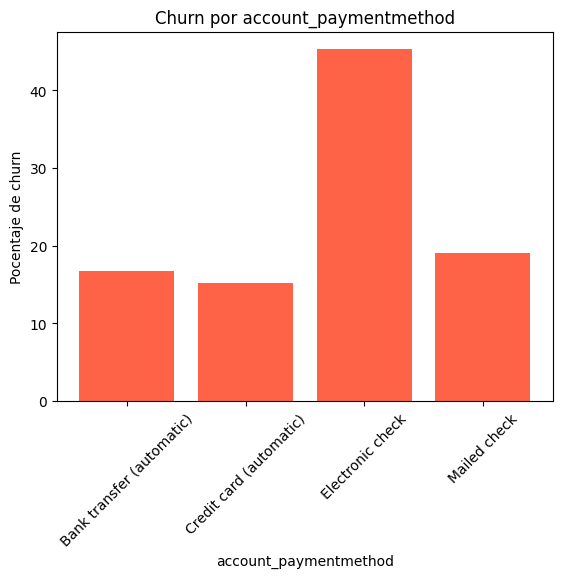

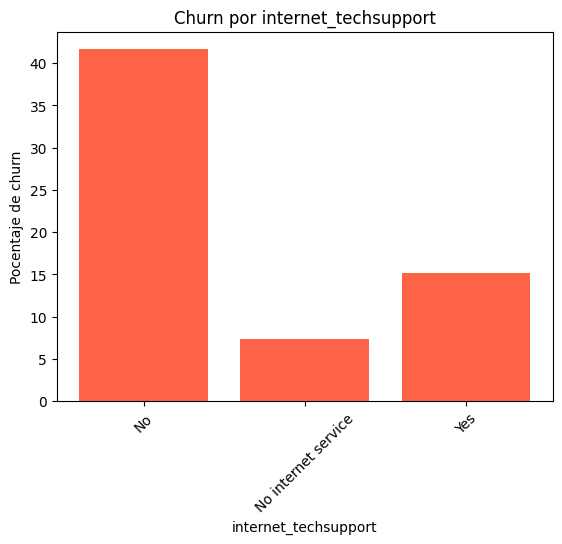

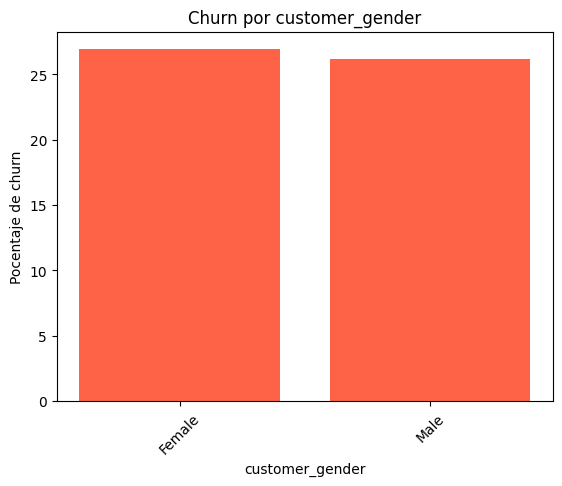

In [67]:
def plot_churn_por_categoria(column):
    tabla = pd.crosstab(data[column], data['churn'], normalize = 'index') * 100
    churn_rate = tabla['Yes']

    plt.figure()
    plt.bar(churn_rate.index.astype(str), churn_rate.values, color = 'tomato')
    plt.xlabel(column)
    plt.ylabel('Pocentaje de churn')
    plt.title(f'Churn por {column}')
    plt.xticks(rotation=45)

    plt.savefig(f'imagenes/churn_por_{column}.png',
            dpi=300,
            bbox_inches='tight')
    plt.show

columnas = ['account_contract',
          'account_paperlessbilling',
          'account_paymentmethod',
          'internet_techsupport',
          'customer_gender']

for col in columnas:
    plot_churn_por_categoria(col)

# **Análisis de correlación entre variables**

In [68]:
variables_numericas = data.select_dtypes(include = ['int64', 'float64'])

matriz_corr = variables_numericas.corr()
matriz_corr

,customer_seniorcitizen,customer_tenure,account_charges_monthly,account_charges_total,daily_accounts,churn_bin
customer_seniorcitizen,1.000000,0.016567,0.220173,0.103006,0.220173,0.150889
customer_tenure,0.016567,1.000000,0.247900,0.826178,0.247900,-0.352229
account_charges_monthly,0.220173,0.247900,1.000000,0.651174,1.000000,0.193356
account_charges_total,0.103006,0.826178,0.651174,1.000000,0.651174,-0.198324
daily_accounts,0.220173,0.247900,1.000000,0.651174,1.000000,0.193356
churn_bin,0.150889,-0.352229,0.193356,-0.198324,0.193356,1.000000


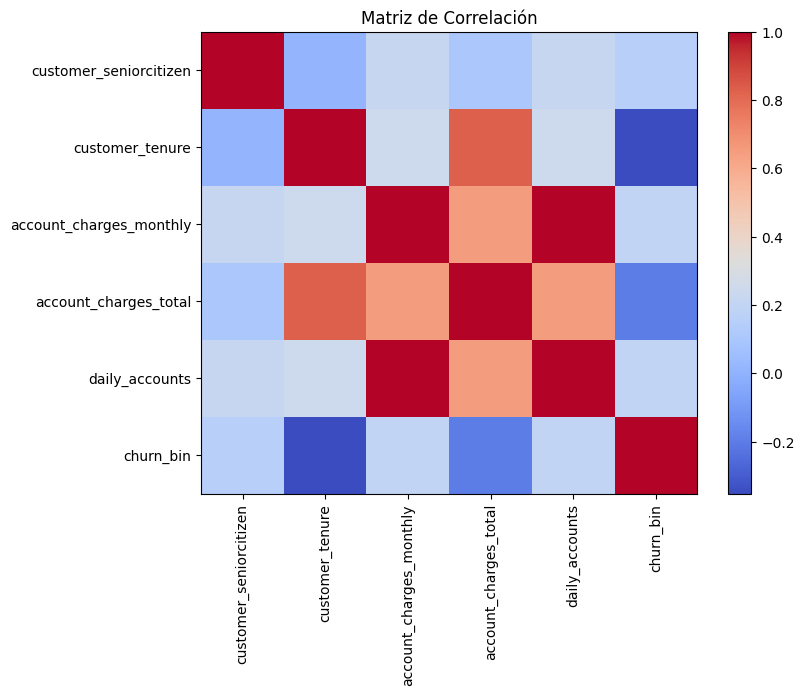

In [69]:
plt.figure(figsize = (8,6))
plt.imshow(matriz_corr, cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.xticks(range(len(matriz_corr.columns)), matriz_corr.columns, rotation=90)
plt.yticks(range(len(matriz_corr.columns)), matriz_corr.columns)

plt.title('Matriz de Correlación')

plt.savefig('imagenes/matriz_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

In [70]:
data.select_dtypes(include=['int64','float64']).corr()['churn_bin'].sort_values(ascending = False)

churn_bin                  1.000000
account_charges_monthly    0.193356
daily_accounts             0.193356
customer_seniorcitizen     0.150889
account_charges_total     -0.198324
customer_tenure           -0.352229
Name: churn_bin, dtype: float64

In [71]:
columnas_binarias = ['phone_phoneservice',
                     'account_paperlessbilling']

data[columnas_binarias] = data[columnas_binarias].replace({'Yes': 1, 'No': 0})
data.head()

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,daily_accounts,churn_bin
0,0002-ORFBO,No,Female,0,Yes,Yes,9,1,No,DSL,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667,0
1,0003-MKNFE,No,Male,0,No,No,9,1,Yes,DSL,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667,0
2,0004-TLHLJ,Yes,Male,0,No,No,4,1,No,Fiber optic,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333,1
3,0011-IGKFF,Yes,Male,1,Yes,No,13,1,No,Fiber optic,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667,1
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,1,No,Fiber optic,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667,1


In [72]:
cols_bin = ['phone_multiplelines',
            'internet_techsupport',
            'internet_streamingtv',
            'internet_streamingmovies']

data = pd.get_dummies(data, columns = cols_bin, drop_first = True)

In [73]:
data.columns

Index(['customerid', 'churn', 'customer_gender', 'customer_seniorcitizen',
       'customer_partner', 'customer_dependents', 'customer_tenure',
       'phone_phoneservice', 'internet_internetservice',
       'internet_onlinesecurity', 'internet_onlinebackup',
       'internet_deviceprotection', 'account_contract',
       'account_paperlessbilling', 'account_paymentmethod',
       'account_charges_monthly', 'account_charges_total', 'daily_accounts',
       'churn_bin', 'phone_multiplelines_No phone service',
       'phone_multiplelines_Yes', 'internet_techsupport_No internet service',
       'internet_techsupport_Yes', 'internet_streamingtv_No internet service',
       'internet_streamingtv_Yes',
       'internet_streamingmovies_No internet service',
       'internet_streamingmovies_Yes'],
      dtype='str')

In [74]:
data.head()

,customerid,churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,internet_internetservice,internet_onlinesecurity,...,daily_accounts,churn_bin,phone_multiplelines_No phone service,phone_multiplelines_Yes,internet_techsupport_No internet service,internet_techsupport_Yes,internet_streamingtv_No internet service,internet_streamingtv_Yes,internet_streamingmovies_No internet service,internet_streamingmovies_Yes
0,0002-ORFBO,No,Female,0,Yes,Yes,9,1,DSL,No,...,2.186667,0,False,False,False,True,False,True,False,False
1,0003-MKNFE,No,Male,0,No,No,9,1,DSL,No,...,1.996667,0,False,True,False,False,False,False,False,True
2,0004-TLHLJ,Yes,Male,0,No,No,4,1,Fiber optic,No,...,2.463333,1,False,False,False,False,False,False,False,False
3,0011-IGKFF,Yes,Male,1,Yes,No,13,1,Fiber optic,No,...,3.266667,1,False,False,False,False,False,True,False,True
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,1,Fiber optic,No,...,2.796667,1,False,False,False,True,False,True,False,False


In [75]:
servicios_cols = [col for col in data.columns if col.endswith('_Yes')]

data['total_servicios'] = data[servicios_cols].sum(axis=1)

matriz_total_servicios = data[['total_servicios', 'churn_bin']].corr()
matriz_total_servicios

,total_servicios,churn_bin
total_servicios,1.000000,0.004375
churn_bin,0.004375,1.000000


# **Informe Final**

## **Introducción**

La tasa de cancelaciones de clientes (churn rate) representa uno de los mayores desafíos para una empresa, pues afecta directamente los ingresos y la estabilidad del negocio. Comprender los factores que influyen en la decisión de los clientes de cancelar los servicios de una empresa permiten tomar acciones estratégicas para disminuir el porcentaje de abandono. 

Este proyecto forma parte del desafío "Churn de Clientes" en la empresa TelecomX, la cual está enfrentando una esta problemática.

El objetivo principal es comprender los factores que influyen en la pérdida de clientes mediante un proceso se Extracción, Transformación y Carga (ETL) y un Análisis Exploratorio de Datos (EDA), donde se identificaron patrones de evasión (churn), se detectaron las variables asociadas a cancelaciones y se prepararon los datos para futuros modelos predictivos.


## **Limpieza y tratamiento de datos**

Para garantizar la calidad del análisis, se realizó la limpieza y tratamiento de los datos, lo que permitió estandarizar la información de la base de datos y dejarla preparada para su posterior manejo. 

A continuación se enlista el tratamiento que se le dio a la base de datos.

- Se realizó la extracción de la base de datos de la API de TelecomX.
- Se unificaron los nombres en las columnas y en la información de las entradas.
- Se modificó el tipo de datos de la columna account_charges_total, de string a float64.
- Se verificaron valores faltantes en el dataset.
- Se verificaron valores faltantes en la columna customerid.
- Se identificaron valores vacíos en la variable account_charges_total, los cuales fueron tratados adecuadamente.
- Se verificaron los valores únicos en la columna churn, y se encontraron valores faltantes, los cuales fueron eliminados del dataset debido a que sólo representaban el ~3% de los datos.
- Se creó la columna daily_accounts con la información del costo diario para el cliente de los servicios que tiene contratados.
- Se transformaron variables categóricas binarias ("Yes"/"No") a formato numérico (0 y 1).
- Se aplicó One-Hot Encoding a variables categóricas con múltiples categorías.
- Se crearon variables derivadas, como total_servicios, para analizar el efecto acumulativo de los servicios contratados.
- Se verificaron los tipos de datos para asegurar compatibilidad en el análisis estadístico.

Todo esto permitió trabajar con un dataset limpio y estructurado para proceder con el análisis exploratorio.


## **Análisis exploratorio de datos**

### **Distribución de Churn**

- Se analizó la proporción de clientes que cancelaron VS los que permanecen. 
- Se observó que el 26.5% de clientes cancelaron.

<p align='center'>
  <img src='imagenes/distribucion_de_churn.png' width='650'>
</p>


### **Conteo de cancelación VS variables numéricas**

Se analizaron las siguientes variables claves para entender la relación entre la permanencia y el comportamiento de gastos de los clientes. 

- customer_tenure (meses de contrato)
- account_charges_monthly (cargos mensuales)
- account_charges_total (cargos totales acumulados)
- daily_accounts (cargos diarios)

**Observaciones importantes**

- La variable customer_tenure muestra una media de 32 meses y una desviación estándar de 24.56, indicando la coexistencia de clientes muy nuevos y clientes con larga permanencia.
- El cargo mensual promedio es de 64.76, con valores que oscilan entre 18.25 y 118.75.
- El cargo total acumulado mostró una distribución sesgada hacia valores altos, reflejando la presencia de clientes con larga permanencia y alto gasto.


**customer_tenure VS churn**

<p align='center'>
  <img src='imagenes/churn_por_customer_tenure.png' width='650'>
</p>

La antigüedad es una de las variables más influyentes en el comportamiento del usuario, ya que los clientes que deciden abandonar el servicio tienden a hacerlo en las etapas tempranas de su relación con la empresa, lo que sugiere que el riesgo de churn es significativamente más alto durante los primeros meses de permanencia.


**account_charges_monthly VS churn**

<p align='center'>
  <img src='imagenes/churn_por_account_charges_monthly.png' width='650'>
</p>

Existe una correlación directa entre el costo del servicio y la deserción, ya que los clientes con cargos mensuales más elevados parecen tener una mayor probabilidad de cancelar, lo que sugiere una marcada sensibilidad al precio o insatisfacción respecto al costo; esta tendencia se confirma al observar que el grupo con churn presenta una mediana de cargos mensuales más alta, mientras que el grupo que no cancela muestra una mediana menor y valores más dispersos.

**account_charges_total VS churn**

<p align='center'>
  <img src='imagenes/churn_por_account_charges_total.png' width='650'>
</p>

El grupo de clientes que se queda presenta cargos totales acumulados significativamente mayores en comparación con el grupo de clientes que abandonan, cuyos cargos totales acumulados son mucho menores debido a que este comportamiento es consistente con la variable customer_tenure; dado que los clientes que abandonan suelen hacerlo de forma prematura, su gasto total acumulado es naturalmente más bajo. No obstante, el grupo churn muestra algunos outliers altos, los cuales podrían representar a clientes con una antigüedad considerable que decidieron cancelar su servicio recientemente.

**daily_accounts VS churn**

<p align='center'>
  <img src='imagenes/churn_por_daily_accounts.png' width='650'>
</p>

Se observa que podría existir cierta relación entre mayor número de cuentas diarias y churn, pero visualmente la separación no es tan fuerte. Esta variable parece tener menor poder discriminativo por sí sola ya que se calculó a partir de la variable account_charges_monthly.


### **Recuento de cancelación por variables categóricas**

Se consideraron las siguientes variables:

- account_contract (tipo de contrato)
- account_paperlessbilling (pago electrónico)
- account_paymentmethod (método de pago)
- internet_techsupport (servicio de soporte técnico)
- customer_gender (género del cliente)


**account_contract VS churn**

<p align='center'>
  <img src='imagenes/churn_por_account_contract.png' width='650'>
</p>

En el gráfico podemos observar que la gran mayoría de clientes que abandonaron la empresa fueron los que tienen un contrato de mes a mes (~43%). Por el contrario, los clientes con contratos de uno o dos años tienen un índice mucho menor de abandono, siendo los que tienen contratos de dos años los que tienen una relación más estable con la empresa. 

Esto sugiere que el tipo de contrato es una variable muy relevante para explicar la tasa de abandono. Una posible explicación es que los contratos a largo plazo funcionan como un mecanismo de retención del cliente, mientras que los contratos mensuales le dan más libertad y facilidad al usuario para cancelar los servicios contratados.

**account_paperlessbilling VS churn**

<p align='center'>
  <img src='imagenes/churn_por_account_paperlessbilling.png' width='650'>
</p>

Se observa que los clientes que utilizan facturación electrónica (paperless) representan aproximadamente el doble de cancelaciones en comparación con aquellos que no la utilizan. Sin embargo, el tipo de factura no es necesariamente causa directa de churn, sino que podría estar asociada a clientes que prefieren lo digital. 

**account_paymentmethod VS churn**

<p align='center'>
  <img src='imagenes/churn_por_account_paymentmethod.png' width='650'>
</p>

En este gráfico, el hallazgo más relevante es que más de la mitad de los clientes que cancelaron utilizaban el cheque electrónico (Electronic check), un porcentaje significativamente superior al de cualquier otra modalidad. En contraste, los métodos automáticos, como la transferencia bancaria y la tarjeta de crédito, presentan niveles de deserción mucho menores, mientras que el pago mediante cheque enviado por correo se mantiene en un nivel intermedio de riesgo.

Este análisis sugiere una asociación clara entre la forma de pago y la estabilidad del cliente: aquellos que utilizan pagos automáticos muestran una mayor retención, posiblemente debido a que estos sistemas generan una mayor dificultad para cancelar. Por el contrario, la alta probabilidad de churn en quienes usan cheque electrónico podría estar vinculada a un menor compromiso con el servicio o a una posible correlación con contratos de tipo mes a mes, los cuales facilitan la salida del cliente.

**internet_techsupport VS churn**

<p align='center'>
  <img src='imagenes/churn_por_internet_techsupport.png' width='650'>
</p>

En la figura se puede observar una marcada diferencia entre la retención de usuarios según su acceso a servicios de asistencia técnica, ya que una mayor proporción de clientes que cancelaron no contaban con soporte técnico, mientras que el porcentaje de churn es significativamente menor en el grupo de clientes que sí contaban con ese servicio. Por otro lado, los clientes sin servicio de internet representan una pequeña fracción de las cancelaciones, reforzando la idea de que la ausencia de soporte técnico está asociada con una mayor probabilidad de abandono.

Por lo que podríamos concluir que la variable internet_techsupport funciona como un factor de retención clave, ya que contar con ese respaldo aumenta la percepción del valor de la empresa y no contar con este factor podría llevar al abandono al sentirse el cliente sin ningún tipo de respaldo ante incidentes.

**customer_gender VS churn**

<p align='center'>
  <img src='imagenes/churn_por_customer_gender.png' width='650'>
</p>


En este gráfico se puede observar que el a diferencia de variables como el tipo de contrato, método de pago o soporte técnico, el género no muestra una asociación relevante con churn, lo que sugiere que el abandono del servicio no depende significativamente del género.

### **Correlaciones**

Se construyó una matriz de correlación para identificar las variables con mayor correlación con churn. 

<p align='center'>
  <img src='imagenes/matriz_correlacion.png' width='650'>
</p>

La variable customer_tenure presentó la mayor correlación con la evasión (-0.35), sugiriendo que los clientes con menor antigüedad presentan mayor probabilidad de cancelación.
En cuanto a los cargos mensuales, se observó una correlación positiva moderada (~0.19) entre el costo mensual y la evasión, lo que podría indicar que clientes con planes más costosos presentan mayor sensibilidad al abandono.
El cargo total acumulado presentó correlación negativa con churn (-0.19), consistente con la relación observada entre antigüedad y retención.

Con este análisis se concluye que la variable con mayor correlación es customer_tenure (meses de contrato). Esto indica que la antigüedad del cliente es el factor más relevante en la cancelación de servicios.

## **Conclusiones e insights**

- Los clientes que cancelan presentan una antigüedad considerablemente menor.
- El boxplot muestra que el churn se concentra en los primeros meses del servicio.
- La correlación entre churn y tenure fue de las más altas entre variables numéricas.
- Se observa mayor churn en clientes con cargos mensuales elevados.
- Aunque presenta variabilidad amplia, el churn se concentra en clientes con menor acumulado total (account_charges_total).
daily_accounts muestra un comportamiento similar al cargo mensual.
- El churn se concentra fuertemente en contratos mes a mes.
- Más del 57% de los clientes que cancelaron utilizaban Electronic check.
- Los clientes sin soporte técnico presentan mayor proporción de churn.
- Los clientes con facturación electrónica muestran mayor churn.
- No se observan diferencias significativas en el abandono entre hombres y mujeres.

**Los datos sugieren que el churn no es aleatorio, sino que responde a un patrón de cliente nuevo + contrato flexible + falta de soporte técnico**


## **Recomendaciones**

- Implementar estrategias de retención temprana dirigidas a clientes nuevos.
- Diseñar incentivos para migrar clientes de contratos mensuales a contratos anuales.
- Revisar la estructura de los precios para clientes con pagos altos y contratos mensuales.
- Ofrecer paquetes personalizados de acuerdo a los servicios extra acorde a las necesidades del cliente.
- Implementar campañas de seguimiento durante los primeros meses de los nuevos clientes.
